# ECE1508 - Course Project
##  Federated Learning Architectures for WiFi-Based Human Activity Recognition

## 1. Setup & Imports

In [1]:
import numpy as np
import os
import glob
import networkx as nx
import copy
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset, Dataset, WeightedRandomSampler
from torchvision.models import resnet50, densenet121
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## 2. Data Loading & Preprocessing

- Each sample is a CSI matrix of shape 1 × 250 × 90 (channels × time steps × subcarriers).
- Data are min-max normalised to [0, 1].
- There are 7 activity classes: lying down, falling, walking, running, sitting down, standing up, and background.

In [2]:
def load_UT_HAR(root_dir):
    expected = ["X_train", "X_val", "X_test", "y_train", "y_val", "y_test"]
    data = {}
    for folder in ["data", "label"]:
        files = glob.glob(os.path.join(root_dir, folder, "*.csv"))
        for path in files:
            key = os.path.basename(path).split(".")[0]
            if key not in expected:
                continue
            arr = np.load(path, allow_pickle=True)
            if folder == "data":
                arr = arr.reshape(len(arr), 1, 250, 90)
                arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
                arr = torch.tensor(arr, dtype=torch.float32)
            else:
                arr = torch.tensor(arr, dtype=torch.long)
            data[key] = arr
    return data

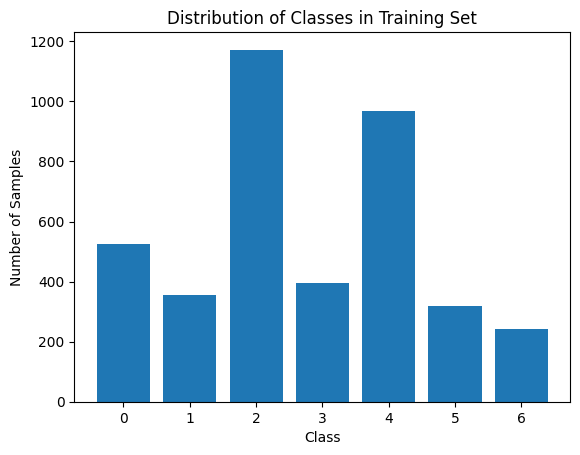

X_train shape: torch.Size([3977, 1, 250, 90])


In [3]:
wifi = load_UT_HAR("UT_HAR")

# Plot distribution of classes in training set
unique, counts = np.unique(wifi["y_train"].numpy(), return_counts=True)
plt.bar(unique, counts)
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Distribution of Classes in Training Set")
plt.show()

# Print shapes of datasets
print("X_train shape:", wifi["X_train"].shape)

- Dataset is relitively small and its distribution is imbalanced. We will use data augmentation and weighted sampler to increase the size of the training set and balance the classes.

In [4]:
class DataAugmentation:
    def __init__(self, noise=0.01, max_shift=5, scale_range=(0.9, 1.1)):
        self.noise = noise
        self.max_shift = max_shift
        self.scale_range = scale_range

    def __call__(self, x):
        x = x + self.noise * torch.randn_like(x)
        shift = torch.randint(-self.max_shift, self.max_shift + 1, (1,)).item()
        x = torch.roll(x, shifts=shift, dims=2)
        x = x * torch.empty(1).uniform_(*self.scale_range).item()
        return x

def expand_dataset(data, labels, augmenter, factor=1):
    augmented_data = []
    augmented_labels = []

    for _ in range(factor):
        for x, y in zip(data, labels):
            x_aug = augmenter(x)
            augmented_data.append(x_aug.unsqueeze(0))
            augmented_labels.append(y.unsqueeze(0))

    new_data = torch.cat([data] + augmented_data, dim=0)
    new_labels = torch.cat([labels] + augmented_labels, dim=0)
    return new_data, new_labels
    
def get_weight(labels):
    classes, counts = torch.unique(labels, return_counts=True)
    total_count = len(labels)
    class_weights = total_count / (len(classes) * counts.float())
    sample_weights = class_weights[labels]
    return sample_weights

def data_loader(data, labels, factor=0, batch_size=64, shuffle=True, augmenter=None):
    if augmenter is not None:
        data, labels = expand_dataset(data, labels, augmenter, factor=factor)
    dataset = TensorDataset(data, labels)
    if shuffle:
        sample_weights = get_weight(labels)
        sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
        return DataLoader(dataset, batch_size=batch_size, sampler=sampler)
    else:
        return DataLoader(dataset, batch_size=batch_size, shuffle=False)

In [5]:
augmenter = DataAugmentation(noise=0.02, max_shift=5, scale_range=(0.9, 1.1))

X_train, y_train = wifi['X_train'], wifi['y_train']
X_val, y_val = wifi['X_val'], wifi['y_val']
X_test, y_test = wifi['X_test'], wifi['y_test']

NUM_CLASSES = int(y_train.max().item()) + 1

train_loader = data_loader(X_train, y_train, factor=1, batch_size=64, shuffle=True, augmenter=augmenter)
val_loader = data_loader(X_val, y_val, batch_size=64, shuffle=False, augmenter=None)
test_loader = data_loader(X_test, y_test, batch_size=64, shuffle=False, augmenter=None)

Train batches: 125, Val batches: 8, Test batches: 8
Images shape: torch.Size([64, 1, 250, 90])
Labels shape: torch.Size([64])
Label values: tensor([0, 1, 2, 3, 4, 5, 6])


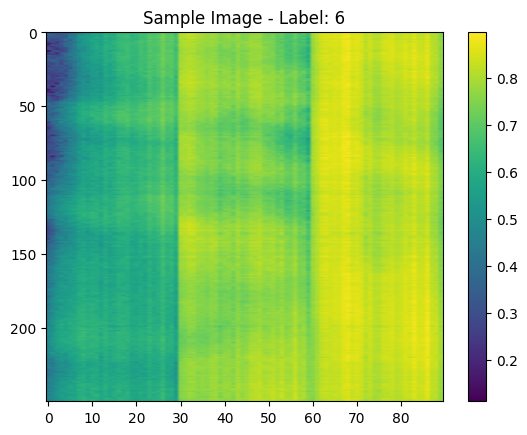

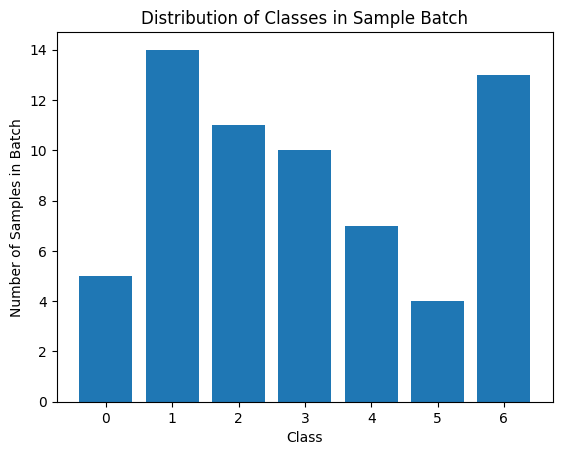

In [6]:
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

images, labels = next(iter(train_loader))
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Label values:", labels.unique())

sample_image, sample_label = images[0], labels[0]
plt.imshow(sample_image.squeeze(), aspect='auto', cmap='viridis')
plt.title(f"Sample Image - Label: {sample_label.item()}")
plt.colorbar()
plt.show()

batch_labels = labels.numpy()
unique, counts = np.unique(batch_labels, return_counts=True)
plt.bar(unique, counts)
plt.xlabel("Class")
plt.ylabel("Number of Samples in Batch")
plt.title("Distribution of Classes in Sample Batch")
plt.show()

In [7]:
print("Dataset sizes")
print("Before augmentation - Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))
print("After augmentation - Train:", len(train_loader.dataset), "Val:", len(val_loader.dataset), "Test:", len(test_loader.dataset))

Dataset sizes
Before augmentation - Train: 3977 Val: 496 Test: 500
After augmentation - Train: 7954 Val: 496 Test: 500


## 3. Model Definitions

### 3.1. Custom CNN

In [8]:
class CNNModel(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 31 * 11, 128)
        self.relu4 = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = self.flatten(x)
        x = self.relu4(self.fc1(x))
        x = self.fc2(x)
        return x

### 3.2. ResNet-50

In [9]:
class ResNet50Model(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.base = resnet50(weights=None)
        self.base.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base.fc = nn.Linear(self.base.fc.in_features, num_classes)

    def forward(self, x):
        return self.base(x)

### 3.3. DenseNet-121

In [10]:
class DenseNetModel(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.base = densenet121(weights=None)
        self.base.features.conv0 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base.classifier = nn.Linear(self.base.classifier.in_features, num_classes)

    def forward(self, x):
        return self.base(x)

In [11]:
MODEL_BUILDERS = {
    'CNN': lambda: CNNModel(NUM_CLASSES),
    'ResNet50': lambda: ResNet50Model(NUM_CLASSES),
    'DenseNet': lambda: DenseNetModel(NUM_CLASSES),
}

MODELS = list(MODEL_BUILDERS.keys())

def count_params(model):
    return sum(p.numel() for p in model.parameters())

print('Model Parameter Counts')
for name, builder in MODEL_BUILDERS.items():
    m = builder()
    print(f'{name} params: {count_params(m)/1e6:.2f} M')

Model Parameter Counts
CNN params: 2.82 M
ResNet50 params: 23.52 M
DenseNet params: 6.95 M


## 4. Hyperparameter Tuning

In [12]:
def hyper_train(model, loader, epochs=3, lr=1e-3):
    
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    total_loss = 0.0
    n_batches = 0
    train_acc = 0.0

    for epoch in range(epochs):
        correct = 0
        samples = 0
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(X)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            n_batches += 1
            preds = outputs.argmax(dim=1)
            correct += (preds == y).sum().item()
            samples += y.size(0)
        train_acc = 100.0 * correct / max(samples, 1)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/n_batches:.4f}, Train Accuracy: {train_acc:.2f}%")

    return model, total_loss / max(n_batches, 1), train_acc

In [13]:
# Evaluation
@torch.no_grad()
def hyper_evaluate(model, loader):

    model.eval()
    all_preds = []
    all_labels = []
    loss = 0.0
    
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        outputs = model(X)
        loss += nn.CrossEntropyLoss()(outputs, y).item()
        preds = outputs.argmax(dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(y.cpu())
    
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    acc = 100.0 * (all_preds == all_labels).mean()
    return loss / len(loader), acc

In [14]:
cnn_model = CNNModel(num_classes=7).to(device)
cnn_train_loss = hyper_train(
    model=cnn_model,
    loader=train_loader,
    epochs=5,
    lr=0.001
)

cnn_test_loss, cnn_test_acc = hyper_evaluate(
    model=cnn_model,
    loader=val_loader,
)

print(f"Validation loss: {cnn_test_loss:.4f}, Validation accuracy: {cnn_test_acc:.2f}%")

Epoch 1/5 - Loss: 1.6252, Train Accuracy: 36.82%
Epoch 2/5 - Loss: 1.3447, Train Accuracy: 62.23%
Epoch 3/5 - Loss: 1.1541, Train Accuracy: 71.98%
Epoch 4/5 - Loss: 1.0112, Train Accuracy: 78.80%
Epoch 5/5 - Loss: 0.8986, Train Accuracy: 84.54%
Validation loss: 0.3828, Validation accuracy: 85.89%


### 4.1. Random Grid Search

In [15]:
def cnn_random_grid_search(options, model_name, num_trials):
    best_acc = 0
    best_config = None
    for trial in range(num_trials):
        t_lr = np.random.choice(options["lr_options"])
        t_batch_size = np.random.choice(options["batch_size_options"])
        t_epochs = np.random.choice(options["epoch_options"])

        print(f"\nTrial {trial+1}: lr={t_lr}, batch_size={t_batch_size}, epochs={t_epochs}")
        
        match model_name:
            case "cnn":
                model = CNNModel(num_classes=7).to(device)
            case "resnet":
                model = ResNet50Model(num_classes=7).to(device)
            case "densenet":
                model = DenseNetModel(num_classes=7).to(device)
        
        trial_train_dataset = data_loader(X_train, y_train, factor=1, batch_size=int(t_batch_size), shuffle=True, augmenter=augmenter)
        trial_val_dataset = data_loader(X_val, y_val, batch_size=int(t_batch_size), shuffle=False, augmenter=None)
        
        hyper_train(model=model, loader=trial_train_dataset, epochs=t_epochs, lr=t_lr)
        val_loss, val_acc = hyper_evaluate(model=model, loader=trial_val_dataset)
        
        print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.2f}%")
        
        if val_acc > best_acc:
            best_acc = val_acc
            best_config = {"lr": t_lr, "batch_size": t_batch_size, "epochs": t_epochs}

    print(f"\nBest config: {best_config}, Validation Accuracy: {best_acc:.4f}")

In [16]:
options = {
    "lr_options": [0.0001, 0.0005, 0.001, 0.005, 0.01],
    "batch_size_options": [16, 32, 64, 128],
    "epoch_options": [5]
}
cnn_random_grid_search(options, "cnn", num_trials=10)


Trial 1: lr=0.005, batch_size=16, epochs=5
Epoch 1/5 - Loss: 1.9541, Train Accuracy: 14.31%
Epoch 2/5 - Loss: 1.9503, Train Accuracy: 14.36%
Epoch 3/5 - Loss: 1.9491, Train Accuracy: 14.65%
Epoch 4/5 - Loss: 1.9485, Train Accuracy: 14.16%
Epoch 5/5 - Loss: 1.9481, Train Accuracy: 14.68%
Validation Loss: 1.9372, Validation Accuracy: 29.44%

Trial 2: lr=0.001, batch_size=128, epochs=5
Epoch 1/5 - Loss: 1.6973, Train Accuracy: 33.69%
Epoch 2/5 - Loss: 1.4926, Train Accuracy: 53.55%
Epoch 3/5 - Loss: 1.3257, Train Accuracy: 64.57%
Epoch 4/5 - Loss: 1.1966, Train Accuracy: 71.46%
Epoch 5/5 - Loss: 1.0844, Train Accuracy: 77.81%
Validation Loss: 0.5891, Validation Accuracy: 78.23%

Trial 3: lr=0.01, batch_size=16, epochs=5
Epoch 1/5 - Loss: 1.9845, Train Accuracy: 14.45%
Epoch 2/5 - Loss: 1.9660, Train Accuracy: 13.68%
Epoch 3/5 - Loss: 1.9599, Train Accuracy: 13.99%
Epoch 4/5 - Loss: 1.9568, Train Accuracy: 13.78%
Epoch 5/5 - Loss: 1.9549, Train Accuracy: 14.65%
Validation Loss: 1.9380, Va

In [17]:
def cnn_grid_search(options, model_name):
    best_acc = 0
    best_config = None
    trial = 0
    total_trials = len(options["lr_options"]) * len(options["batch_size_options"]) * len(options["epoch_options"])
    for t_lr in options["lr_options"]:
        for t_batch_size in options["batch_size_options"]:
            for t_epochs in options["epoch_options"]:
                trial += 1
                print(f"\nTrial {trial}/{total_trials}: lr={t_lr}, batch_size={t_batch_size}, epochs={t_epochs}")
        
                match model_name:
                    case "cnn":
                        model = CNNModel(num_classes=7).to(device)
                    case "resnet":
                        model = ResNet50Model(num_classes=7).to(device)
                    case "densenet":
                        model = DenseNetModel(num_classes=7).to(device)
                
                trial_train_dataset = data_loader(X_train, y_train, factor=1, batch_size=int(t_batch_size), shuffle=True, augmenter=augmenter)
                trial_val_dataset = data_loader(X_val, y_val, batch_size=int(t_batch_size), shuffle=False, augmenter=None)
                
                hyper_train(model=model, loader=trial_train_dataset, epochs=t_epochs, lr=t_lr)
                val_loss, val_acc = hyper_evaluate(model=model, loader=trial_val_dataset)
                
                print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.2f}%")
                
                if val_acc > best_acc:
                    best_acc = val_acc
                    best_config = {"lr": t_lr, "batch_size": t_batch_size, "epochs": t_epochs}

    print(f"\nBest config: {best_config}, Validation Accuracy: {best_acc:.4f}")

In [18]:
options = {
    "lr_options": [0.0001, 0.0005, 0.001, 0.005, 0.01],
    "batch_size_options": [16, 32, 64, 128],
    "epoch_options": [5]
}
cnn_grid_search(options, "cnn")


Trial 1/20: lr=0.0001, batch_size=16, epochs=5
Epoch 1/5 - Loss: 1.7189, Train Accuracy: 33.73%
Epoch 2/5 - Loss: 1.5259, Train Accuracy: 52.53%
Epoch 3/5 - Loss: 1.3829, Train Accuracy: 61.21%
Epoch 4/5 - Loss: 1.2687, Train Accuracy: 67.94%
Epoch 5/5 - Loss: 1.1815, Train Accuracy: 71.34%
Validation Loss: 0.7683, Validation Accuracy: 73.19%

Trial 2/20: lr=0.0001, batch_size=32, epochs=5
Epoch 1/5 - Loss: 1.8760, Train Accuracy: 22.35%
Epoch 2/5 - Loss: 1.6714, Train Accuracy: 46.67%
Epoch 3/5 - Loss: 1.5325, Train Accuracy: 56.47%
Epoch 4/5 - Loss: 1.4214, Train Accuracy: 62.36%
Epoch 5/5 - Loss: 1.3254, Train Accuracy: 67.60%
Validation Loss: 0.8243, Validation Accuracy: 71.17%

Trial 3/20: lr=0.0001, batch_size=64, epochs=5
Epoch 1/5 - Loss: 1.8840, Train Accuracy: 24.99%
Epoch 2/5 - Loss: 1.7225, Train Accuracy: 44.30%
Epoch 3/5 - Loss: 1.5910, Train Accuracy: 53.26%
Epoch 4/5 - Loss: 1.4961, Train Accuracy: 57.67%
Epoch 5/5 - Loss: 1.4249, Train Accuracy: 60.27%
Validation Loss

In [19]:
train_loader = data_loader(X_train, y_train, factor=0, batch_size=32, shuffle=True, augmenter=augmenter)
val_loader = data_loader(X_val, y_val, batch_size=32, shuffle=False, augmenter=None)
test_loader = data_loader(X_test, y_test, batch_size=32, shuffle=False, augmenter=None)

In [20]:
cnn_model = CNNModel(num_classes=7).to(device)
cnn_train_loss = hyper_train(
    model=cnn_model,
    loader=train_loader,
    epochs=5,
    lr=0.001
)

cnn_test_loss, cnn_test_acc = hyper_evaluate(
    model=cnn_model,
    loader=test_loader,
)

print(f"Test loss: {cnn_test_loss:.4f}, Test accuracy: {cnn_test_acc:.2f}%")

Epoch 1/5 - Loss: 1.6364, Train Accuracy: 35.76%
Epoch 2/5 - Loss: 1.3517, Train Accuracy: 60.88%
Epoch 3/5 - Loss: 1.1409, Train Accuracy: 73.22%
Epoch 4/5 - Loss: 0.9703, Train Accuracy: 83.63%
Epoch 5/5 - Loss: 0.8413, Train Accuracy: 88.84%
Test loss: 0.4580, Test accuracy: 83.00%


In [21]:
resnet_model = ResNet50Model(num_classes=7).to(device)
resnet_train_loss = hyper_train(
    model=resnet_model,
    loader=train_loader,
    epochs=5,
    lr=0.001
)

resnet_test_loss, resnet_test_acc = hyper_evaluate(
    model=resnet_model,
    loader=test_loader,
)

print(f"Test loss: {resnet_test_loss:.4f}, Test accuracy: {resnet_test_acc:.2f}%")

Epoch 1/5 - Loss: 0.9988, Train Accuracy: 66.76%
Epoch 2/5 - Loss: 0.7412, Train Accuracy: 84.13%
Epoch 3/5 - Loss: 0.5934, Train Accuracy: 90.19%
Epoch 4/5 - Loss: 0.5037, Train Accuracy: 92.33%
Epoch 5/5 - Loss: 0.4395, Train Accuracy: 94.47%
Test loss: 3.4067, Test accuracy: 52.20%


In [22]:
densenet_model = DenseNetModel(num_classes=7).to(device)
densenet_train_loss = hyper_train(
    model=densenet_model,
    loader=train_loader,
    epochs=5,
    lr=0.001
)

densenet_test_loss, densenet_test_acc = hyper_evaluate(
    model=densenet_model,
    loader=test_loader,
)

print(f"Test loss: {densenet_test_loss:.4f}, Test accuracy: {densenet_test_acc:.2f}%")

Epoch 1/5 - Loss: 0.7930, Train Accuracy: 70.93%
Epoch 2/5 - Loss: 0.6011, Train Accuracy: 86.52%
Epoch 3/5 - Loss: 0.4859, Train Accuracy: 91.20%
Epoch 4/5 - Loss: 0.4208, Train Accuracy: 92.58%
Epoch 5/5 - Loss: 0.3678, Train Accuracy: 95.02%
Test loss: 3.1912, Test accuracy: 45.40%


## 5. Utility Functions

In [23]:
# Local training step
def train_local(model, loader, epochs=3, lr=1e-3):
    
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    total_loss = 0.0
    n_batches = 0
    train_acc = 0.0

    for epoch in range(epochs):
        correct = 0
        samples = 0
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(X)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            n_batches += 1
            preds = outputs.argmax(dim=1)
            correct += (preds == y).sum().item()
            samples += y.size(0)
        train_acc = 100.0 * correct / max(samples, 1)

    return model, total_loss / max(n_batches, 1), train_acc

In [24]:
# Evaluation
@torch.no_grad()
def evaluate(model, loader):

    model.eval()
    all_preds = []
    all_labels = []
    
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        preds = model(X).argmax(dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(y.cpu())
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    acc = 100.0 * (all_preds == all_labels).mean()
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return acc, f1

In [25]:
# FedAvg aggregation
def fedavg_aggregate(global_model, client_models, weights=None):

    K = len(client_models)
    if weights is None:
        weights = [1.0 / K] * K
    global_sd = global_model.state_dict()
    client_sds = [m.state_dict() for m in client_models]
    for key in global_sd:
        if global_sd[key].dtype.is_floating_point:
            global_sd[key] = sum(w * sd[key] for w, sd in zip(weights, client_sds))
        else:
            global_sd[key] = client_sds[0][key]
    global_model.load_state_dict(global_sd)
    return global_model

In [26]:
# Communication cost
def model_size_M(model):
    return count_params(model) / 1e6

## 6. Client Data Partitioning

- The training set is split into K equal IID partitions, one per client.

In [27]:
def iid_partition(dataset, K, batch_size=64):

    n = len(dataset)
    indices = torch.randperm(n).tolist()
    splits = np.array_split(indices, K)
    loaders = []
    for idx in splits:
        subset = Subset(dataset, idx.tolist())
        loaders.append(DataLoader(subset, batch_size=batch_size, shuffle=True))
    return loaders

## 7. Centralized Federated Learning (FedAvg)

- Protocol per round:
  1. Broadcast global model to all K clients.
  2. Each client trains locally for E epochs.
  3. Server collects and averages all client models.
- Communication cost per round: 2 × K × |θ| (K uploads + K downloads).

In [28]:
def run_fedavg(model_name, K=10, T=10, E=3, batch_size=64, lr=1e-3):

    client_loaders = iid_partition(train_loader.dataset, K, batch_size)
    global_model = MODEL_BUILDERS[model_name]().to(device)
    params = model_size_M(global_model)
    comm_per_round = 2 * K * params

    round_local_train_acc = []
    round_global_train_acc = []
    round_val_acc = []
    round_val_f1 = []

    for t in range(1, T + 1):
        client_models = []
        client_train_accs = []
        for loader in client_loaders:
            client = copy.deepcopy(global_model)
            client, _, train_acc = train_local(client, loader, epochs=E, lr=lr)
            client_models.append(client)
            client_train_accs.append(train_acc)

        global_model = fedavg_aggregate(global_model, client_models)
        local_avg_train_acc = sum(client_train_accs) / len(client_train_accs)
        global_train_acc, _ = evaluate(global_model, train_loader)
        acc, f1 = evaluate(global_model, val_loader)

        round_local_train_acc.append(local_avg_train_acc)
        round_global_train_acc.append(global_train_acc)
        round_val_acc.append(acc)
        round_val_f1.append(f1)
        print(
            f'Round {t:2d}/{T}  '
            f'LocalAvgTrain={local_avg_train_acc:.2f}%  '
            f'GlobalTrain={global_train_acc:.2f}%  '
            f'GlobalVal={acc:.2f}%  '
            f'F1={f1:.4f}'
        )

    total_comm = comm_per_round * T
    print(f'Total comm cost: {total_comm:.1f} M params')

    return {
        'round_local_train_acc': round_local_train_acc,
        'round_global_train_acc': round_global_train_acc,
        'round_val_acc': round_val_acc,
        'round_val_f1': round_val_f1,
        'final_val_acc': round_val_acc[-1],
        'final_val_f1': round_val_f1[-1],
        'comm_M': total_comm,
        'model': global_model
    }

### 7.1. Run Experiments
- **Experiment Configuration**
  - K: Total number of clients
  - T: Number of global communication rounds
  - E: Local training epochs per round per client
  - batch_size: Mini-batch size during local training
  - lr: Learning rate for Adam optimiser

In [29]:
K_values = [5, 10]
lr_values = [0.001, 0.0005, 0.0001]
T = 10
E = 5
batch_size = 32

fedavg_grid = {}
print(f'Grid Search Config: K={K_values}, lr={lr_values}, T={T}, E={E}, batch_size={batch_size}')

Grid Search Config: K=[5, 10], lr=[0.001, 0.0005, 0.0001], T=10, E=5, batch_size=32


- **Model Training**

In [30]:
fedavg_grid['CNN'] = {}
for K in K_values:
    fedavg_grid['CNN'][K] = {}
    for lr in lr_values:
        print('-' * 60)
        print(f'Model=CNN  K={K}  lr={lr}')
        fedavg_grid['CNN'][K][lr] = run_fedavg('CNN', K=K, T=T, E=E, batch_size=batch_size, lr=lr)

------------------------------------------------------------
Model=CNN  K=5  lr=0.001
Round  1/10  LocalAvgTrain=55.09%  GlobalTrain=36.16%  GlobalVal=47.58%  F1=0.3395
Round  2/10  LocalAvgTrain=73.37%  GlobalTrain=64.17%  GlobalVal=66.33%  F1=0.6259
Round  3/10  LocalAvgTrain=87.08%  GlobalTrain=81.69%  GlobalVal=84.48%  F1=0.8226
Round  4/10  LocalAvgTrain=94.54%  GlobalTrain=91.98%  GlobalVal=90.12%  F1=0.8796
Round  5/10  LocalAvgTrain=97.36%  GlobalTrain=93.49%  GlobalVal=91.94%  F1=0.9051
Round  6/10  LocalAvgTrain=98.57%  GlobalTrain=97.31%  GlobalVal=94.76%  F1=0.9327
Round  7/10  LocalAvgTrain=98.74%  GlobalTrain=98.54%  GlobalVal=95.16%  F1=0.9432
Round  8/10  LocalAvgTrain=99.35%  GlobalTrain=98.89%  GlobalVal=95.56%  F1=0.9456
Round  9/10  LocalAvgTrain=99.55%  GlobalTrain=99.17%  GlobalVal=95.56%  F1=0.9506
Round 10/10  LocalAvgTrain=99.72%  GlobalTrain=99.47%  GlobalVal=95.56%  F1=0.9485
Total comm cost: 282.3 M params
----------------------------------------------------

In [31]:
fedavg_grid['ResNet50'] = {}
for K in K_values:
    fedavg_grid['ResNet50'][K] = {}
    for lr in lr_values:
        print('-' * 60)
        print(f'Model=ResNet50  K={K}  lr={lr}')
        fedavg_grid['ResNet50'][K][lr] = run_fedavg('ResNet50', K=K, T=T, E=E, batch_size=batch_size, lr=lr)

------------------------------------------------------------
Model=ResNet50  K=5  lr=0.001
Round  1/10  LocalAvgTrain=81.97%  GlobalTrain=14.79%  GlobalVal=13.91%  F1=0.0489
Round  2/10  LocalAvgTrain=85.77%  GlobalTrain=47.15%  GlobalVal=46.17%  F1=0.3449
Round  3/10  LocalAvgTrain=87.83%  GlobalTrain=59.27%  GlobalVal=61.29%  F1=0.5327
Round  4/10  LocalAvgTrain=92.18%  GlobalTrain=40.66%  GlobalVal=53.63%  F1=0.3720
Round  5/10  LocalAvgTrain=92.68%  GlobalTrain=87.20%  GlobalVal=90.12%  F1=0.8766
Round  6/10  LocalAvgTrain=93.46%  GlobalTrain=49.46%  GlobalVal=63.10%  F1=0.5467
Round  7/10  LocalAvgTrain=95.02%  GlobalTrain=50.94%  GlobalVal=56.65%  F1=0.5451
Round  8/10  LocalAvgTrain=95.72%  GlobalTrain=92.26%  GlobalVal=90.73%  F1=0.9072
Round  9/10  LocalAvgTrain=96.35%  GlobalTrain=93.74%  GlobalVal=91.73%  F1=0.9130
Round 10/10  LocalAvgTrain=97.71%  GlobalTrain=91.75%  GlobalVal=89.31%  F1=0.8894
Total comm cost: 2351.6 M params
----------------------------------------------

In [32]:
fedavg_grid['DenseNet'] = {}
for K in K_values:
    fedavg_grid['DenseNet'][K] = {}
    for lr in lr_values:
        print('-' * 60)
        print(f'Model=DenseNet  K={K}  lr={lr}')
        fedavg_grid['DenseNet'][K][lr] = run_fedavg('DenseNet', K=K, T=T, E=E, batch_size=batch_size, lr=lr)

------------------------------------------------------------
Model=DenseNet  K=5  lr=0.001
Round  1/10  LocalAvgTrain=86.04%  GlobalTrain=29.04%  GlobalVal=41.53%  F1=0.2030
Round  2/10  LocalAvgTrain=90.22%  GlobalTrain=59.34%  GlobalVal=64.11%  F1=0.6124
Round  3/10  LocalAvgTrain=92.58%  GlobalTrain=68.22%  GlobalVal=76.81%  F1=0.7673
Round  4/10  LocalAvgTrain=94.77%  GlobalTrain=95.55%  GlobalVal=95.97%  F1=0.9476
Round  5/10  LocalAvgTrain=96.00%  GlobalTrain=92.15%  GlobalVal=91.13%  F1=0.8928
Round  6/10  LocalAvgTrain=96.13%  GlobalTrain=97.26%  GlobalVal=96.77%  F1=0.9585
Round  7/10  LocalAvgTrain=97.28%  GlobalTrain=56.25%  GlobalVal=55.44%  F1=0.5886
Round  8/10  LocalAvgTrain=98.11%  GlobalTrain=95.12%  GlobalVal=95.16%  F1=0.9372
Round  9/10  LocalAvgTrain=97.79%  GlobalTrain=97.44%  GlobalVal=95.77%  F1=0.9594
Round 10/10  LocalAvgTrain=98.06%  GlobalTrain=82.65%  GlobalVal=77.42%  F1=0.8122
Total comm cost: 695.5 M params
-----------------------------------------------

- Best config

In [33]:
best_config = {}
for model_name in MODELS:
    best_acc = -1
    for K in K_values:
        for lr in lr_values:
            r = fedavg_grid[model_name][K][lr]
            if r['final_val_acc'] > best_acc:
                best_acc = r['final_val_acc']
                best_config[model_name] = {'K': K, 'lr': lr}

for model_name in MODELS:
    cfg = best_config[model_name]
    print(f"{model_name}: best K={cfg['K']}, lr={cfg['lr']}")

CNN: best K=5, lr=0.001
ResNet50: best K=5, lr=0.0005
DenseNet: best K=5, lr=0.0001


- Final model evaluation

In [34]:
print(f"{'Model':<12} {'K':>4} {'lr':>8} {'Test Acc':>10} {'Test F1':>10}")
print('-' * 50)
for model_name in MODELS:
    cfg = best_config[model_name]
    best_model = fedavg_grid[model_name][cfg['K']][cfg['lr']]['model']
    test_acc, test_f1 = evaluate(best_model, test_loader)
    print(f"{model_name:<12} {cfg['K']:>4} {cfg['lr']:>8} {test_acc:>9.2f}% {test_f1:>10.4f}")

Model           K       lr   Test Acc    Test F1
--------------------------------------------------
CNN             5    0.001     95.60%     0.9329
ResNet50        5   0.0005     97.20%     0.9671
DenseNet        5   0.0001     98.20%     0.9700


### 7.2. Results & Visualisation

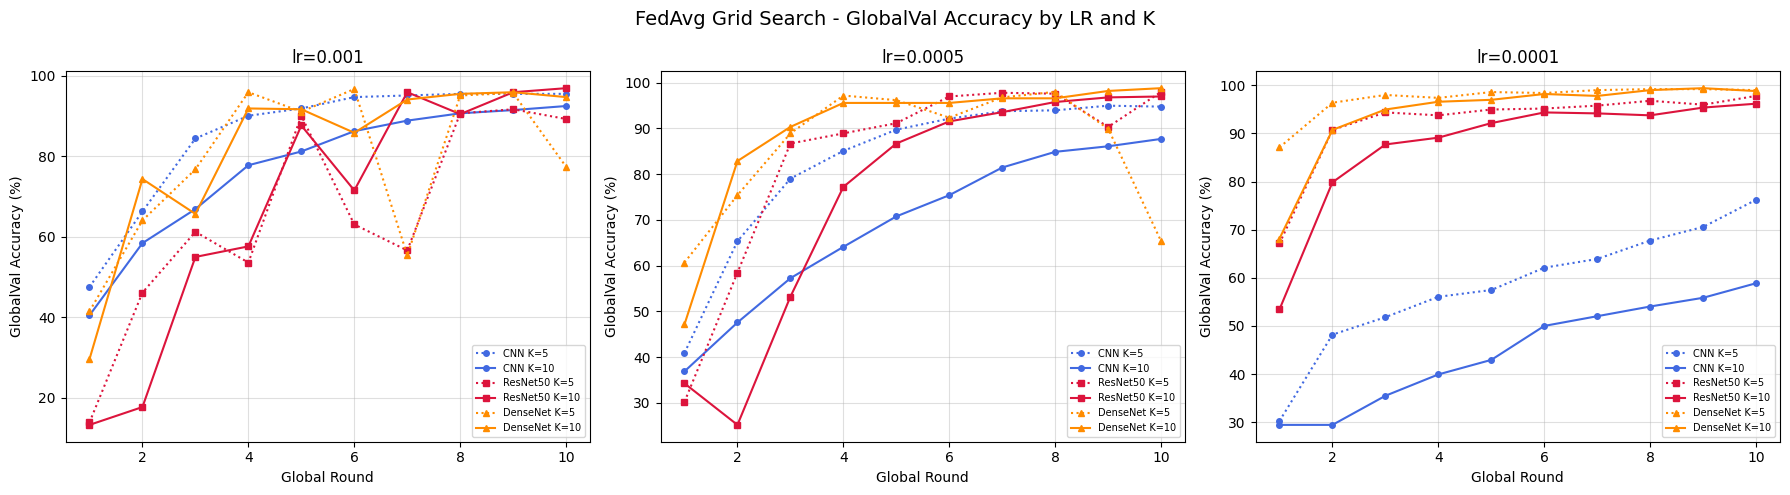

In [35]:
rounds = list(range(1, T + 1))
colors = {'CNN': 'royalblue', 'ResNet50': 'crimson', 'DenseNet': 'darkorange'}
markers = {'CNN': 'o', 'ResNet50': 's', 'DenseNet': '^'}
linestyles = {5: ':', 10: '-'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, lr in zip(axes, lr_values):
    for model_name in MODELS:
        for K in K_values:
            r = fedavg_grid[model_name][K][lr]
            ax.plot(
                rounds, r['round_val_acc'],
                color=colors[model_name],
                linestyle=linestyles[K],
                marker=markers[model_name],
                markersize=4,
                label=f'{model_name} K={K}'
            )
    ax.set_title(f'lr={lr}', fontsize=12)
    ax.set_xlabel('Global Round')
    ax.set_ylabel('GlobalVal Accuracy (%)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.4)

plt.suptitle('FedAvg Grid Search - GlobalVal Accuracy by LR and K', fontsize=14)
plt.tight_layout()
plt.show()

- Summary table

In [36]:
print('FedAvg Grid Search - Final Results Summary')
print(f"{'Model':<12} {'K':>4} {'LR':>8} {'Val Acc (%)':>11} {'Macro-F1':>10} {'Comm (M params)':>18}")
print('-' * 67)
for K in K_values:
    for model_name in MODELS:
        for lr in lr_values:
            r = fedavg_grid[model_name][K][lr]
            print(f"{model_name:<12} {K:>4} {lr:>8.4f} {r['final_val_acc']:>11.2f} {r['final_val_f1']:>10.4f} {r['comm_M']:>18.1f}")
    print('-' * 67)

FedAvg Grid Search - Final Results Summary
Model           K       LR Val Acc (%)   Macro-F1    Comm (M params)
-------------------------------------------------------------------
CNN             5   0.0010       95.56     0.9485              282.3
CNN             5   0.0005       94.76     0.9379              282.3
CNN             5   0.0001       76.21     0.7217              282.3
ResNet50        5   0.0010       89.31     0.8894             2351.6
ResNet50        5   0.0005       97.98     0.9796             2351.6
ResNet50        5   0.0001       97.78     0.9721             2351.6
DenseNet        5   0.0010       77.42     0.8122              695.5
DenseNet        5   0.0005       65.32     0.6687              695.5
DenseNet        5   0.0001       98.99     0.9809              695.5
-------------------------------------------------------------------
CNN            10   0.0010       92.54     0.9043              564.5
CNN            10   0.0005       87.70     0.8630             

- Convergence plots: LocalAvgTrain, GlobalTrain, GlobalVal

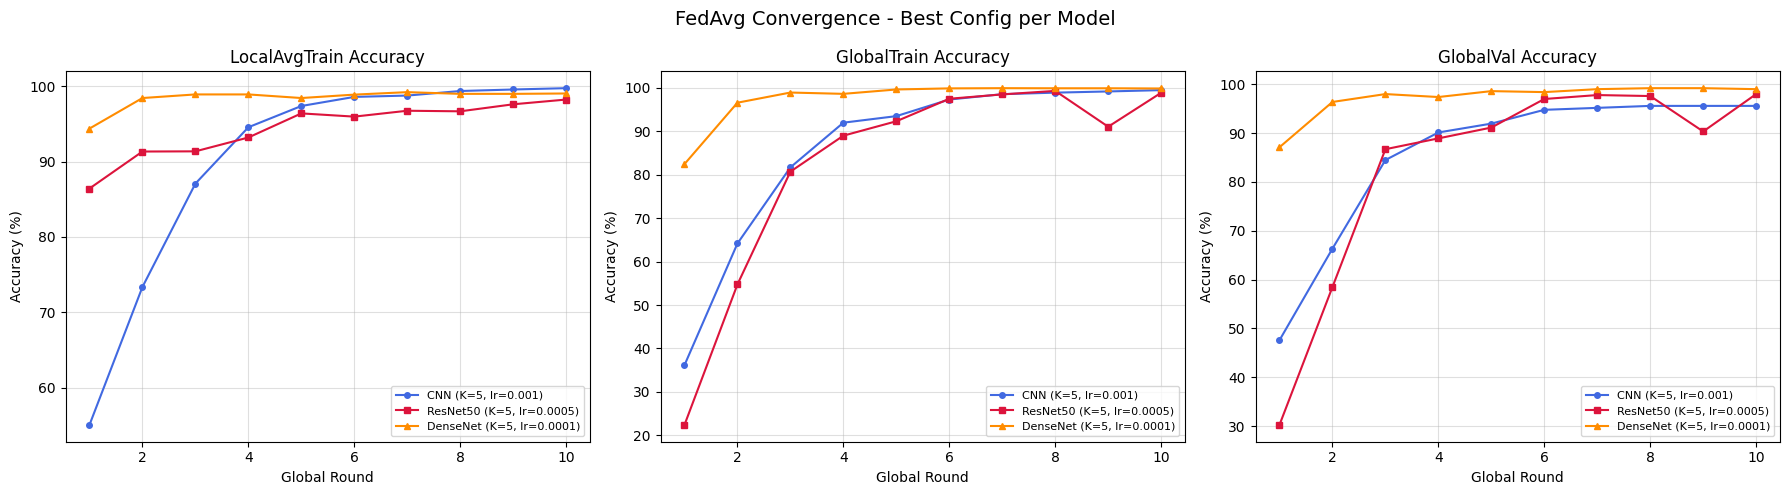

In [37]:
rounds = list(range(1, T + 1))
colors = {'CNN': 'royalblue', 'ResNet50': 'crimson', 'DenseNet': 'darkorange'}
markers = {'CNN': 'o', 'ResNet50': 's', 'DenseNet': '^'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
titles = ['LocalAvgTrain Accuracy', 'GlobalTrain Accuracy', 'GlobalVal Accuracy']
keys = ['round_local_train_acc', 'round_global_train_acc', 'round_val_acc']

for ax, title, key in zip(axes, titles, keys):
    for model_name in MODELS:
        cfg = best_config[model_name]
        r = fedavg_grid[model_name][cfg['K']][cfg['lr']]
        label = f"{model_name} (K={cfg['K']}, lr={cfg['lr']})"
        ax.plot(rounds, r[key], color=colors[model_name], marker=markers[model_name], markersize=4, label=label)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Global Round')
    ax.set_ylabel('Accuracy (%)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

plt.suptitle('FedAvg Convergence - Best Config per Model', fontsize=14)
plt.tight_layout()
plt.show()

- Macro-F1 convergence

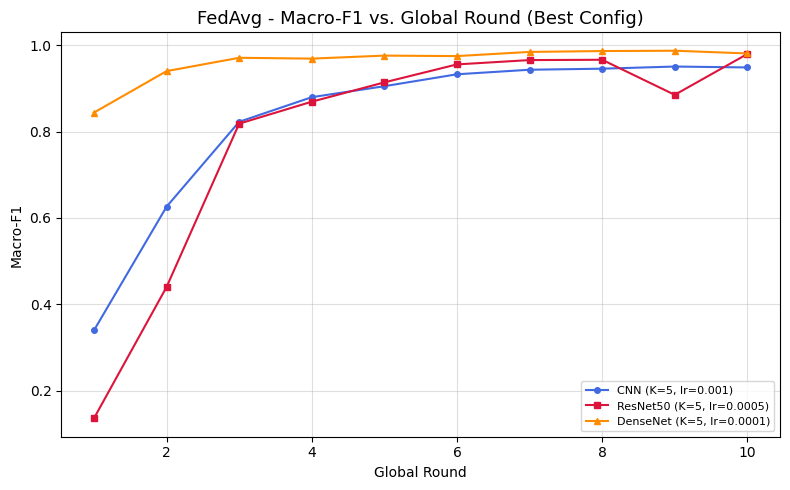

In [38]:
fig, ax = plt.subplots(figsize=(8, 5))
for model_name in MODELS:
    cfg = best_config[model_name]
    r = fedavg_grid[model_name][cfg['K']][cfg['lr']]
    label = f"{model_name} (K={cfg['K']}, lr={cfg['lr']})"
    ax.plot(rounds, r['round_val_f1'], color=colors[model_name], marker=markers[model_name], markersize=4, label=label)

ax.set_title('FedAvg - Macro-F1 vs. Global Round (Best Config)', fontsize=13)
ax.set_xlabel('Global Round')
ax.set_ylabel('Macro-F1')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 8. Decentralized Federated Learning (Graph-based)
- Protocol per round:
  1. Each client sends its current model to its two neighbors in the ring.
  2. Each client receives models from its neighbors and aggregates them (e.g., FedAvg with self + neighbors).
  3. Each client trains locally for E epochs using its updated model.
- Communication cost per round: 2 × K × |θ| (each client uploads 2 times to both its neighbors).

In [39]:
def create_graph(num_clients):
    G = nx.Graph()
    # Add client nodes
    for i in range(num_clients):
        G.add_node(f'Client {i+1}')
    # Add ring edges
    for i in range(num_clients):
        G.add_edge(f'Client {i+1}', f'Client {(i+2) % num_clients + 1}')
    return G

In [40]:
def run_ring_fedavg(model_name, K=10, T=10, E=3, batch_size=64, lr=1e-3):

    client_loaders = iid_partition(train_loader.dataset, K, batch_size)
    initial_model = MODEL_BUILDERS[model_name]().to(device)
    params = model_size_M(initial_model)
    comm_per_round = 2 * K * params

    G = create_graph(K)
    
    client_models = []
    round_val_acc = []
    round_train_acc = []
    round_val_f1 = []

    for t in range(1, T + 1):
        client_train_accs = 0.0
        client_val_accs = 0.0
        client_val_f1s = 0.0
        
        if t == 1:
            init_client_train_accs = 0.0
            for loader in client_loaders:
                client = copy.deepcopy(initial_model)
                client, _, train_acc = train_local(client, loader, epochs=E, lr=lr)
                client_models.append(client)
                init_client_train_accs += train_acc
            
        for node in G.nodes:
            neighbors = list(G.neighbors(node))
            neighbor_indexes = [int(n.split()[1]) - 1 for n in neighbors]
            neighbor_models = [client_models[i] for i in neighbor_indexes]
            idx = int(node.split()[1]) - 1
            client_models[idx] = fedavg_aggregate(client_models[idx], neighbor_models)
            
        for model in client_models:
            idx = client_models.index(model)
            loader = client_loaders[idx]
            model, _, train_acc = train_local(model, loader, epochs=E, lr=lr)
            client_train_accs += train_acc

        # Evaluate client's model on val set
        for model in client_models:
            acc, f1 = evaluate(model, val_loader)
            client_val_accs += acc
            client_val_f1s += f1
        
        round_val_acc.append(client_val_accs / K)
        round_val_f1.append(client_val_f1s / K)
        round_train_acc.append(client_train_accs / K)

        if t == 1:
            print(
                f'Round {t:2d}/{T}  '
                f'InitClientAvgTrain={init_client_train_accs/K:.2f}%  '
                f'ClientAvgTrain={client_train_accs/K:.2f}%  '
                f'ClientAvgVal={round_val_acc[-1]:.2f}%  '
                f'F1={round_val_f1[-1]:.4f}'
            )
        else:
            print(
                f'Round {t:2d}/{T}  '
                f'ClientAvgTrain={client_train_accs/K:.2f}%  '
                f'ClientAvgVal={round_val_acc[-1]:.2f}%  '
                f'F1={round_val_f1[-1]:.4f}'
            )

    total_comm = comm_per_round * T
    print(f'Total comm cost: {total_comm:.1f} M params')

    return {
        'round_train_acc': round_train_acc,
        'round_val_acc': round_val_acc,
        'round_val_f1': round_val_f1,
        'final_val_acc': round_val_acc[-1],
        'final_val_f1': round_val_f1[-1],
        'comm_M': total_comm,
        'client_models': client_models
    }

### 8.1. Run Experiments
- **Experiment Configuration**
  - K: Total number of clients
  - T: Number of global communication rounds
  - E: Local training epochs per round per client
  - batch_size: Mini-batch size during local training
  - lr: Learning rate for Adam optimiser

In [41]:
K_values = [5, 10]
lr_values = [0.001, 0.0005, 0.0001]
T = 10
E = 5
batch_size = 32

ring_grid = {}

print(f'Grid Search Config: K={K_values}, lr={lr_values}, T={T}, E={E}, batch_size={batch_size}')

Grid Search Config: K=[5, 10], lr=[0.001, 0.0005, 0.0001], T=10, E=5, batch_size=32


- **Model Training**

In [42]:
ring_grid['CNN'] = {}
for K in K_values:
    ring_grid['CNN'][K] = {}
    for lr in lr_values:
        print('-' * 60)
        print(f'Model=CNN K={K} lr={lr}')
        ring_grid['CNN'][K][lr] = run_ring_fedavg('CNN', K=K, T=T, E=E, batch_size=batch_size, lr=lr)

------------------------------------------------------------
Model=CNN K=5 lr=0.001
Round  1/10  InitClientAvgTrain=55.14%  ClientAvgTrain=71.84%  ClientAvgVal=65.12%  F1=0.6102
Round  2/10  ClientAvgTrain=83.48%  ClientAvgVal=78.47%  F1=0.7539
Round  3/10  ClientAvgTrain=91.75%  ClientAvgVal=83.63%  F1=0.8181
Round  4/10  ClientAvgTrain=95.63%  ClientAvgVal=88.35%  F1=0.8745
Round  5/10  ClientAvgTrain=96.63%  ClientAvgVal=88.71%  F1=0.8684
Round  6/10  ClientAvgTrain=96.98%  ClientAvgVal=89.96%  F1=0.8816
Round  7/10  ClientAvgTrain=98.99%  ClientAvgVal=92.90%  F1=0.9164
Round  8/10  ClientAvgTrain=99.22%  ClientAvgVal=92.98%  F1=0.9116
Round  9/10  ClientAvgTrain=99.30%  ClientAvgVal=92.82%  F1=0.9130
Round 10/10  ClientAvgTrain=99.32%  ClientAvgVal=92.22%  F1=0.9078
Total comm cost: 282.3 M params
------------------------------------------------------------
Model=CNN K=5 lr=0.0005
Round  1/10  InitClientAvgTrain=49.16%  ClientAvgTrain=66.88%  ClientAvgVal=61.53%  F1=0.5494
Round  2

In [43]:
ring_grid['ResNet50'] = {}
for K in K_values:
    ring_grid['ResNet50'][K] = {}
    for lr in lr_values:
        print('-' * 60)
        print(f'Model=ResNet50 K={K} lr={lr}')
        ring_grid['ResNet50'][K][lr] = run_ring_fedavg('ResNet50', K=K, T=T, E=E, batch_size=batch_size, lr=lr)

------------------------------------------------------------
Model=ResNet50 K=5 lr=0.001
Round  1/10  InitClientAvgTrain=83.03%  ClientAvgTrain=85.44%  ClientAvgVal=65.40%  F1=0.6083
Round  2/10  ClientAvgTrain=90.95%  ClientAvgVal=61.45%  F1=0.5167
Round  3/10  ClientAvgTrain=91.83%  ClientAvgVal=62.90%  F1=0.5615
Round  4/10  ClientAvgTrain=94.47%  ClientAvgVal=62.82%  F1=0.5874
Round  5/10  ClientAvgTrain=94.19%  ClientAvgVal=58.83%  F1=0.5551
Round  6/10  ClientAvgTrain=96.30%  ClientAvgVal=79.56%  F1=0.7616
Round  7/10  ClientAvgTrain=96.08%  ClientAvgVal=73.71%  F1=0.6493
Round  8/10  ClientAvgTrain=95.72%  ClientAvgVal=50.77%  F1=0.4005
Round  9/10  ClientAvgTrain=96.18%  ClientAvgVal=54.35%  F1=0.4579
Round 10/10  ClientAvgTrain=97.54%  ClientAvgVal=58.19%  F1=0.5387
Total comm cost: 2351.6 M params
------------------------------------------------------------
Model=ResNet50 K=5 lr=0.0005
Round  1/10  InitClientAvgTrain=86.72%  ClientAvgTrain=89.69%  ClientAvgVal=62.30%  F1=0.53

In [44]:
ring_grid['DenseNet'] = {}
for K in K_values:
    ring_grid['DenseNet'][K] = {}
    for lr in lr_values:
        print('-' * 60)
        print(f'Model=DenseNet  K={K}  lr={lr}')
        ring_grid['DenseNet'][K][lr] = run_ring_fedavg('DenseNet', K=K, T=T, E=E, batch_size=batch_size, lr=lr)

------------------------------------------------------------
Model=DenseNet  K=5  lr=0.001
Round  1/10  InitClientAvgTrain=84.33%  ClientAvgTrain=90.12%  ClientAvgVal=54.56%  F1=0.4514
Round  2/10  ClientAvgTrain=92.83%  ClientAvgVal=46.57%  F1=0.3297
Round  3/10  ClientAvgTrain=95.37%  ClientAvgVal=60.97%  F1=0.5285
Round  4/10  ClientAvgTrain=96.73%  ClientAvgVal=38.47%  F1=0.2811
Round  5/10  ClientAvgTrain=95.85%  ClientAvgVal=49.44%  F1=0.3907
Round  6/10  ClientAvgTrain=98.06%  ClientAvgVal=48.63%  F1=0.4273
Round  7/10  ClientAvgTrain=97.84%  ClientAvgVal=51.61%  F1=0.3905
Round  8/10  ClientAvgTrain=98.47%  ClientAvgVal=69.80%  F1=0.6534
Round  9/10  ClientAvgTrain=98.44%  ClientAvgVal=70.89%  F1=0.6539
Round 10/10  ClientAvgTrain=98.57%  ClientAvgVal=58.83%  F1=0.5423
Total comm cost: 695.5 M params
------------------------------------------------------------
Model=DenseNet  K=5  lr=0.0005
Round  1/10  InitClientAvgTrain=90.27%  ClientAvgTrain=93.46%  ClientAvgVal=55.28%  F1=0

- Best config

In [45]:
best_config_ring = {}
for model_name in MODELS:
    best_acc = -1
    for K in K_values:
        for lr in lr_values:
            r = ring_grid[model_name][K][lr]
            if r['final_val_acc'] > best_acc:
                best_acc = r['final_val_acc']
                best_config_ring[model_name] = {'K': K, 'lr': lr}

for model_name in MODELS:
    cfg = best_config_ring[model_name]
    print(f"{model_name}: best K={cfg['K']}, lr={cfg['lr']}")

CNN: best K=5, lr=0.001
ResNet50: best K=5, lr=0.0001
DenseNet: best K=5, lr=0.0001


- Final model evaluation

In [46]:
print(f"{'Model':<12} {'K':>4} {'lr':>8} {'Test Acc':>10} {'Test F1':>10}")
print('-' * 50)
for model_name in MODELS:
    cfg = best_config_ring[model_name]
    r = ring_grid[model_name][cfg['K']][cfg['lr']]
    accs, f1s = [], []
    for model in r['client_models']:
        acc, f1 = evaluate(model, test_loader)
        accs.append(acc)
        f1s.append(f1)
    print(f"{model_name:<12} {cfg['K']:>4} {cfg['lr']:>8} {sum(accs)/len(accs):>9.2f}% {sum(f1s)/len(f1s):>10.4f}")

Model           K       lr   Test Acc    Test F1
--------------------------------------------------
CNN             5    0.001     91.72%     0.8947
ResNet50        5   0.0001     91.24%     0.8870
DenseNet        5   0.0001     93.40%     0.9164


### 8.2. Results & Visualisation

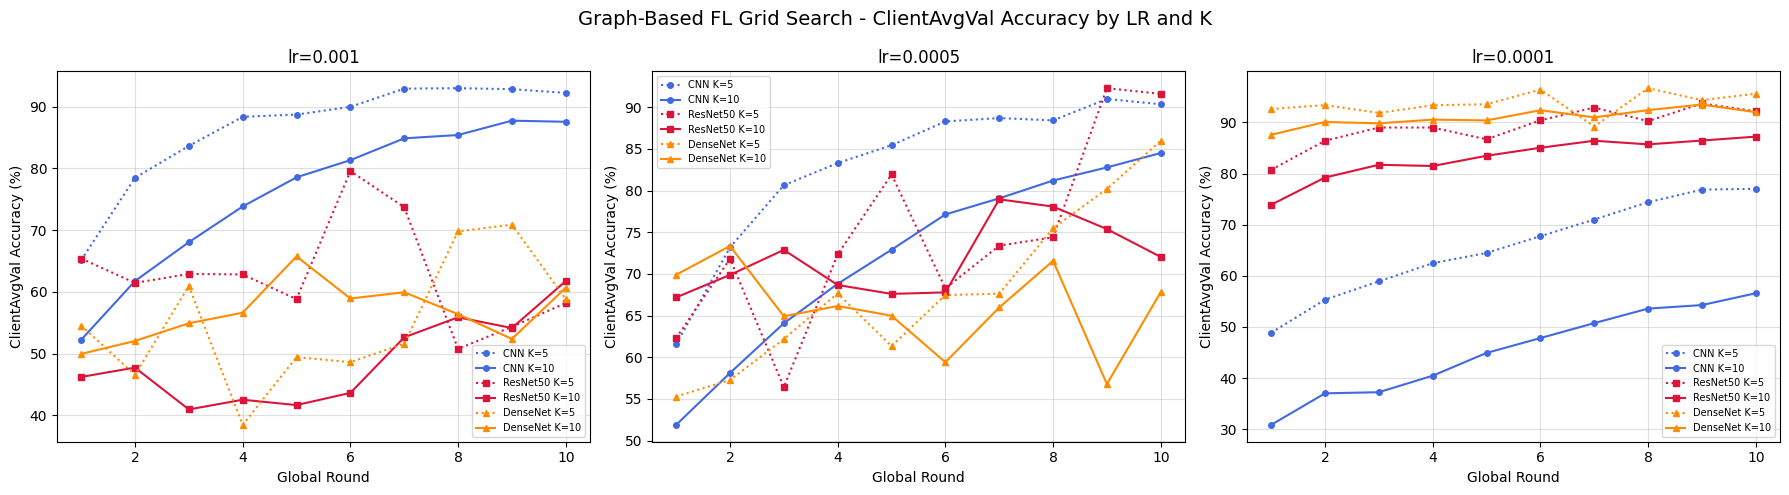

In [47]:
rounds = list(range(1, T + 1))
colors = {'CNN': 'royalblue', 'ResNet50': 'crimson', 'DenseNet': 'darkorange'}
markers = {'CNN': 'o', 'ResNet50': 's', 'DenseNet': '^'}
linestyles = {5: ':', 10: '-'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, lr in zip(axes, lr_values):
    for model_name in MODELS:
        for K in K_values:
            r = ring_grid[model_name][K][lr]
            ax.plot(
                rounds, r['round_val_acc'],
                color=colors[model_name],
                linestyle=linestyles[K],
                marker=markers[model_name],
                markersize=4,
                label=f'{model_name} K={K}'
            )
    ax.set_title(f'lr={lr}', fontsize=12)
    ax.set_xlabel('Global Round')
    ax.set_ylabel('ClientAvgVal Accuracy (%)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.4)

plt.suptitle('Graph-Based FL Grid Search - ClientAvgVal Accuracy by LR and K', fontsize=14)
plt.tight_layout()
plt.show()

- Summary table

In [48]:
print('Graph-Based FL Grid Search - Final Results Summary')
print(f"{'Model':<12} {'K':>4} {'LR':>8} {'Val Acc (%)':>11} {'Macro-F1':>10} {'Comm (M params)':>18}")
print('-' * 67)
for K in K_values:
    for model_name in MODELS:
        for lr in lr_values:
            r = ring_grid[model_name][K][lr]
            print(f"{model_name:<12} {K:>4} {lr:>8.4f} {r['final_val_acc']:>11.2f} {r['final_val_f1']:>10.4f} {r['comm_M']:>18.1f}")
    print('-' * 67)

Graph-Based FL Grid Search - Final Results Summary
Model           K       LR Val Acc (%)   Macro-F1    Comm (M params)
-------------------------------------------------------------------
CNN             5   0.0010       92.22     0.9078              282.3
CNN             5   0.0005       90.36     0.8890              282.3
CNN             5   0.0001       77.02     0.7367              282.3
ResNet50        5   0.0010       58.19     0.5387             2351.6
ResNet50        5   0.0005       91.61     0.9006             2351.6
ResNet50        5   0.0001       92.18     0.9070             2351.6
DenseNet        5   0.0010       58.83     0.5423              695.5
DenseNet        5   0.0005       85.97     0.8451              695.5
DenseNet        5   0.0001       95.60     0.9524              695.5
-------------------------------------------------------------------
CNN            10   0.0010       87.54     0.8469              564.5
CNN            10   0.0005       84.52     0.8262     

- Convergence plots: ClientAvgTrain, ClientAvgVal

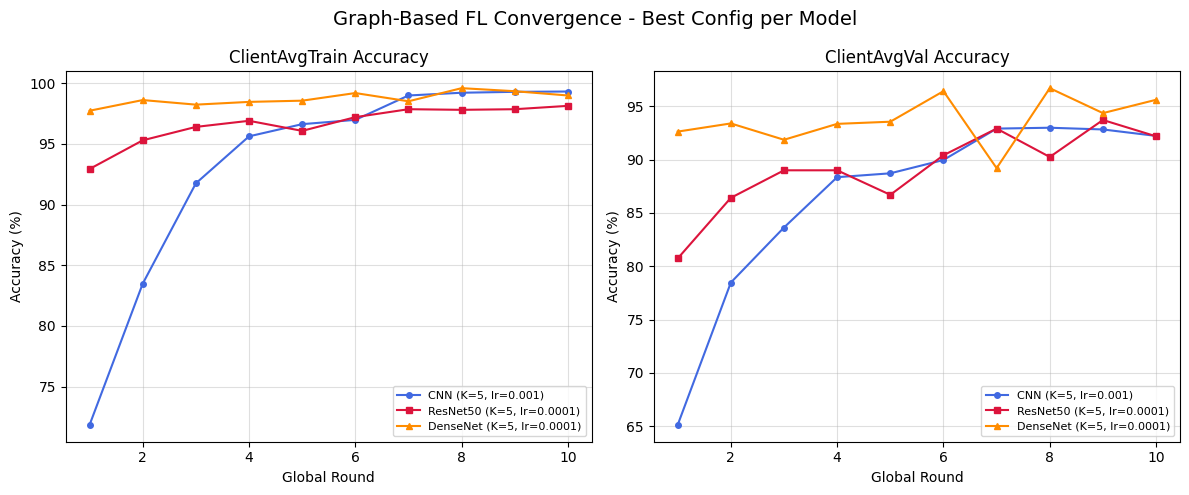

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
titles = ['ClientAvgTrain Accuracy', 'ClientAvgVal Accuracy']
keys = ['round_train_acc', 'round_val_acc']

for ax, title, key in zip(axes, titles, keys):
    for model_name in MODELS:
        cfg = best_config_ring[model_name]
        r = ring_grid[model_name][cfg['K']][cfg['lr']]
        label = f"{model_name} (K={cfg['K']}, lr={cfg['lr']})"
        ax.plot(rounds, r[key], color=colors[model_name], marker=markers[model_name], markersize=4, label=label)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Global Round')
    ax.set_ylabel('Accuracy (%)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

plt.suptitle('Graph-Based FL Convergence - Best Config per Model', fontsize=14)
plt.tight_layout()
plt.show()

- Macro-F1 convergence

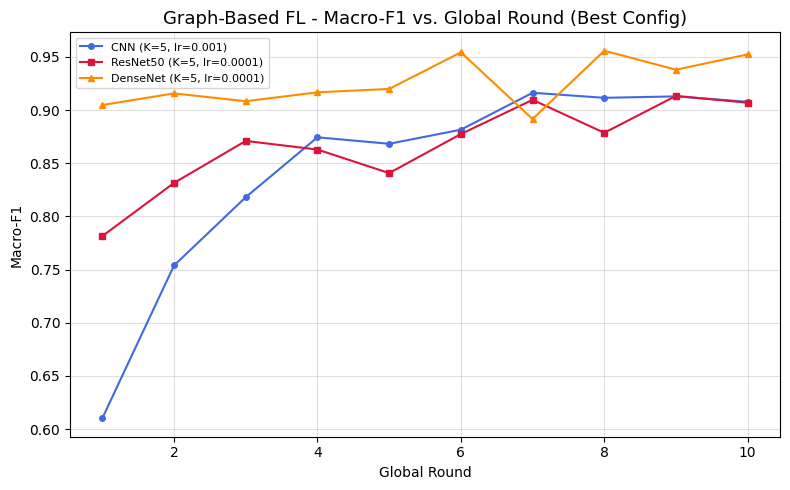

In [50]:
fig, ax = plt.subplots(figsize=(8, 5))
for model_name in MODELS:
    cfg = best_config_ring[model_name]
    r = ring_grid[model_name][cfg['K']][cfg['lr']]
    label = f"{model_name} (K={cfg['K']}, lr={cfg['lr']})"
    ax.plot(rounds, r['round_val_f1'], color=colors[model_name], marker=markers[model_name], markersize=4, label=label)

ax.set_title('Graph-Based FL - Macro-F1 vs. Global Round (Best Config)', fontsize=13)
ax.set_xlabel('Global Round')
ax.set_ylabel('Macro-F1')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
